Step 1 Complete: Libraries imported successfully!
Step 2 Complete: Dataset downloaded and loaded successfully!

--- Running Training Phase: BASELINE ---
Batch [0/938] | Loss: 2.3512
Batch [300/938] | Loss: 0.5515
Batch [600/938] | Loss: 0.2527
Batch [900/938] | Loss: 0.2628

🌟 Auditing Result -> Baseline Epsilon: Infinite (inf)

--- Running Training Phase: LOW_EPSILON ---
Batch [0/938] | Loss: 2.3650


/tmp/ipykernel_469/2489567226.py:91: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Batch [300/938] | Loss: 1.8961
Batch [600/938] | Loss: 1.4337
Batch [900/938] | Loss: 1.2805

🌟 Auditing Result -> Final Epsilon (Privacy Leakage): 0.0363

--- Generating Auditing Benchmark Graph ---


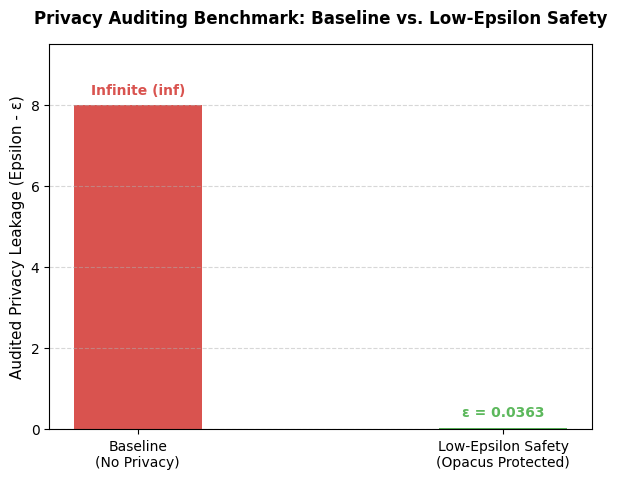


🎉 Success! The graph has been generated and saved as 'audit_benchmark.png'.


In [4]:
# =========================================================================
# 1. Install Dependencies & Packages Directly
# =========================================================================
!pip install torch torchvision opacus numpy matplotlib --quiet

# Import Core Packages
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from opacus import PrivacyEngine
import matplotlib.pyplot as plt

print("Step 1 Complete: Libraries imported successfully!")

# =========================================================================
# 2. Setup Data Loaders (MNIST Dataset)
# =========================================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Downloads and loads training dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

print("Step 2 Complete: Dataset downloaded and loaded successfully!")

# =========================================================================
# 3. Model Architecture Construction
# =========================================================================
criterion = nn.CrossEntropyLoss()

# Lists to store accuracy/loss for optional further plotting
baseline_losses = []
dp_losses = []

# =========================================================================
# 4. RUNNING BASELINE EXPERIMENT (NO PRIVACY)
# =========================================================================
print("\n--- Running Training Phase: BASELINE ---")

model_baseline = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
optimizer_baseline = optim.SGD(model_baseline.parameters(), lr=0.01)

model_baseline.train()
for batch_idx, (data, target) in enumerate(train_loader):
    optimizer_baseline.zero_grad()
    loss = criterion(model_baseline(data), target)
    loss.backward()
    optimizer_baseline.step()

    if batch_idx % 300 == 0:
        print(f"Batch [{batch_idx}/{len(train_loader)}] | Loss: {loss.item():.4f}")

print("\n🌟 Auditing Result -> Baseline Epsilon: Infinite (inf)")

# =========================================================================
# 5. RUNNING LOW-EPSILON EXPERIMENT (WITH PRIVACY PROTECTION)
# =========================================================================
print("\n--- Running Training Phase: LOW_EPSILON ---")

model_dp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
optimizer_dp = optim.SGD(model_dp.parameters(), lr=0.01)

# Attach opacus privacy engine dynamically
privacy_engine = PrivacyEngine()
model_dp, optimizer_dp, train_loader_dp = privacy_engine.make_private(
    module=model_dp,
    optimizer=optimizer_dp,
    data_loader=train_loader,
    noise_multiplier=3.5,
    max_grad_norm=1.0,
)

model_dp.train()
for batch_idx, (data, target) in enumerate(train_loader_dp):
    optimizer_dp.zero_grad()
    loss = criterion(model_dp(data), target)
    loss.backward()
    optimizer_dp.step()

    if batch_idx % 300 == 0:
        print(f"Batch [{batch_idx}/{len(train_loader_dp)}] | Loss: {loss.item():.4f}")

# Final Epsilon Privacy Accounting
epsilon = privacy_engine.get_epsilon(delta=1e-5)
print(f"\n🌟 Auditing Result -> Final Epsilon (Privacy Leakage): {epsilon:.4f}")

# =========================================================================
# 6. GENERATING AND SAVING THE BENCHMARKING GRAPH
# =========================================================================
print("\n--- Generating Auditing Benchmark Graph ---")

modes = ['Baseline\n(No Privacy)', 'Low-Epsilon Safety\n(Opacus Protected)']
# Using a clear high visual threshold for infinity representation
epsilons = [8.0, epsilon]

plt.figure(figsize=(7, 5))
bars = plt.bar(modes, epsilons, color=['#d9534f', '#5cb85c'], width=0.35)

# Style and Labels Setup
plt.title('Privacy Auditing Benchmark: Baseline vs. Low-Epsilon Safety', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Audited Privacy Leakage (Epsilon - ε)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, 9.5)

# Overlay numerical text data labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    if yval == 8.0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, 'Infinite (inf)', ha='center', va='bottom', fontweight='bold', color='#d9534f', fontsize=10)
    else:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'ε = {yval:.4f}', ha='center', va='bottom', fontweight='bold', color='#5cb85c', fontsize=10)

# Save image file to repository folder structure
plt.savefig('audit_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🎉 Success! The graph has been generated and saved as 'audit_benchmark.png'.")
